Problem statement

Ask a home buyer to describe their dream house, and they probably won't begin with the height of the basement ceiling or the proximity to an east-west railroad. But this playground competition's dataset proves that much more influences price negotiations than the number of bedrooms or a white-picket fence.

With 79 explanatory variables describing (almost) every aspect of residential homes in Ames, Iowa, this competition challenges you to predict the final price of each home.

Acknowledgments

The Ames Housing dataset was compiled by Dean De Cock for use in data science education. It's an incredible alternative for data scientists looking for a modernized and expanded version of the often cited Boston Housing dataset.



Import

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

Load

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


Read

In [3]:
train = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/train.csv")
test = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/test.csv")
submission = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv")

In [4]:
train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [5]:
test

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


In [6]:
submission

,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570
3,1464,179317.477511
4,1465,150730.079977
...,...,...
1454,2915,167081.220949
1455,2916,164788.778231
1456,2917,219222.423400
1457,2918,184924.279659


Analysr SalePrice

In [7]:
target = train['SalePrice']

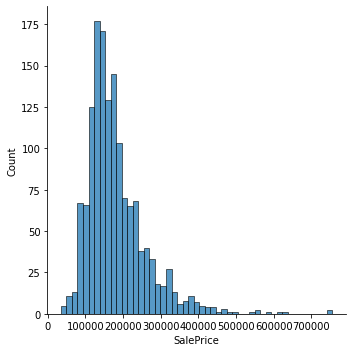

In [8]:
sns.displot(target)

<AxesSubplot:xlabel='SalePrice', ylabel='Count'>

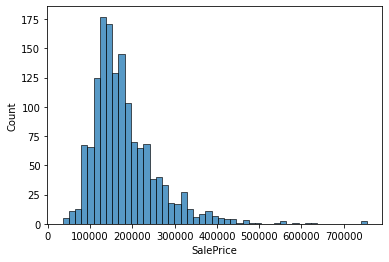

In [9]:
sns.histplot(target)

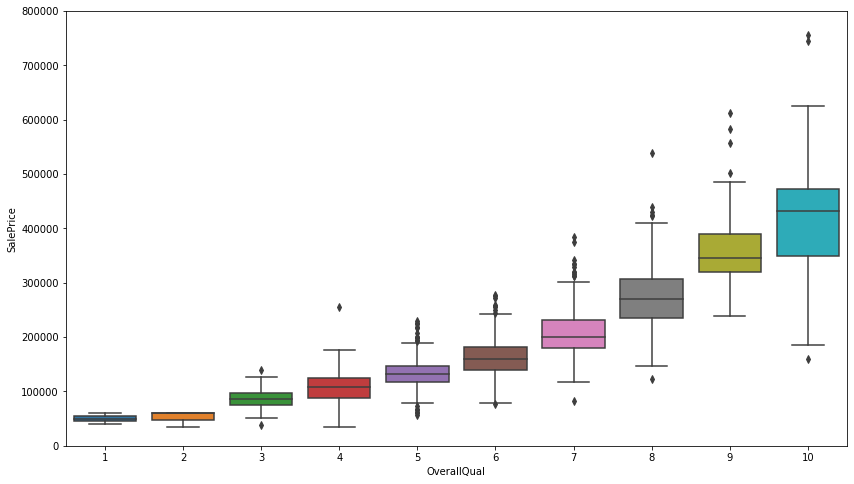

In [10]:
var = 'OverallQual'
data = pd.concat([target, train[var]], axis=1)
f, ax = plt.subplots(figsize=(14, 8))
fig = sns.boxplot(x=var, y=target, data=data)
fig.axis(ymin=0, ymax=800000);


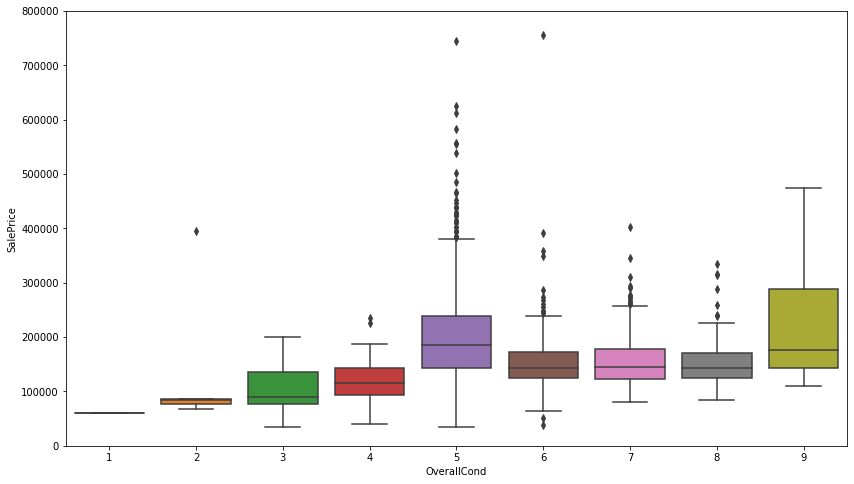

In [11]:
var = 'OverallCond'
data = pd.concat([target, train[var]], axis=1)
f, ax = plt.subplots(figsize=(14, 8))
fig = sns.boxplot(x=var, y=target, data=data)
fig.axis(ymin=0, ymax=800000);

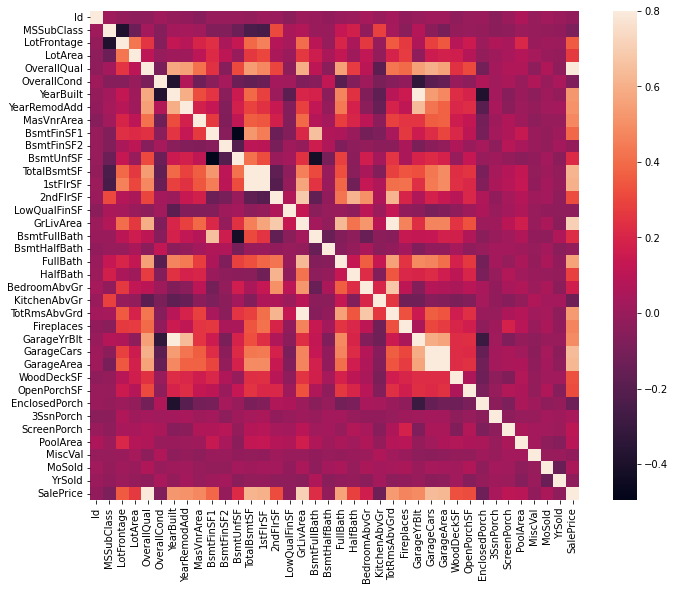

In [12]:
corrmat = train.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True);

Impute train null values

In [13]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imp = IterativeImputer(random_state=42)

for col in train:
    if train[col].dtype=="object":
        train[col].fillna("not listed", inplace=True)
    if train[col].dtype=="int":
        #train[col].fillna(train[col].mode()[0], inplace=True)
        train[col].fillna(train[col].mean(), inplace=True)
    if train[col].dtype=='float':
        train[col] = imp.fit_transform(train[col].values.reshape(-1,1))


In [14]:
train.isnull().sum().sum()

0

Locate and delete outliers

In [15]:
for x in ['SalePrice']:
    q75,q25 = np.percentile(train.loc[:,x],[75,25])
    intr_qr = q75-q25
 
    max = q75+(2*intr_qr)
    min = q25-(2*intr_qr)
 
    train.loc[train[x] < min,x] = np.nan
    train.loc[train[x] > max,x] = np.nan

In [16]:
train['SalePrice'].isnull().sum()

38

In [17]:
train = train.dropna(axis = 0)
train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,not listed,Reg,Lvl,AllPub,...,0,not listed,not listed,not listed,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,not listed,Reg,Lvl,AllPub,...,0,not listed,not listed,not listed,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,not listed,IR1,Lvl,AllPub,...,0,not listed,not listed,not listed,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,not listed,IR1,Lvl,AllPub,...,0,not listed,not listed,not listed,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,not listed,IR1,Lvl,AllPub,...,0,not listed,not listed,not listed,0,12,2008,WD,Normal,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,not listed,Reg,Lvl,AllPub,...,0,not listed,not listed,not listed,0,8,2007,WD,Normal,175000.0
1456,1457,20,RL,85.0,13175,Pave,not listed,Reg,Lvl,AllPub,...,0,not listed,MnPrv,not listed,0,2,2010,WD,Normal,210000.0
1457,1458,70,RL,66.0,9042,Pave,not listed,Reg,Lvl,AllPub,...,0,not listed,GdPrv,Shed,2500,5,2010,WD,Normal,266500.0
1458,1459,20,RL,68.0,9717,Pave,not listed,Reg,Lvl,AllPub,...,0,not listed,not listed,not listed,0,4,2010,WD,Normal,142125.0


In [18]:
target = train['SalePrice']

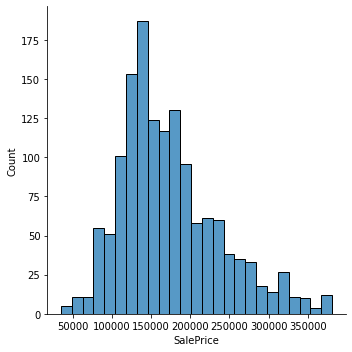

In [19]:
sns.displot(target)

<AxesSubplot:xlabel='SalePrice', ylabel='Count'>

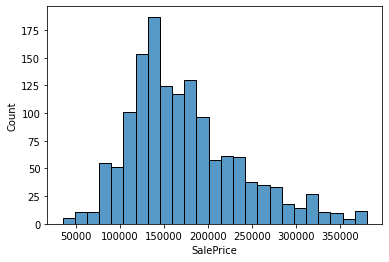

In [20]:
sns.histplot(target)

Drop SalePrice from train

In [21]:
train.drop(['SalePrice'], axis = 1, inplace=True)
train

/opt/conda/lib/python3.7/site-packages/pandas/core/frame.py:4913: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,not listed,Reg,Lvl,AllPub,...,0,0,not listed,not listed,not listed,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,not listed,Reg,Lvl,AllPub,...,0,0,not listed,not listed,not listed,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,not listed,IR1,Lvl,AllPub,...,0,0,not listed,not listed,not listed,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,not listed,IR1,Lvl,AllPub,...,0,0,not listed,not listed,not listed,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,not listed,IR1,Lvl,AllPub,...,0,0,not listed,not listed,not listed,0,12,2008,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,not listed,Reg,Lvl,AllPub,...,0,0,not listed,not listed,not listed,0,8,2007,WD,Normal
1456,1457,20,RL,85.0,13175,Pave,not listed,Reg,Lvl,AllPub,...,0,0,not listed,MnPrv,not listed,0,2,2010,WD,Normal
1457,1458,70,RL,66.0,9042,Pave,not listed,Reg,Lvl,AllPub,...,0,0,not listed,GdPrv,Shed,2500,5,2010,WD,Normal
1458,1459,20,RL,68.0,9717,Pave,not listed,Reg,Lvl,AllPub,...,0,0,not listed,not listed,not listed,0,4,2010,WD,Normal


Combine train and test

In [22]:
combi = train.append(test)
combi

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,not listed,Reg,Lvl,AllPub,...,0,0,not listed,not listed,not listed,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,not listed,Reg,Lvl,AllPub,...,0,0,not listed,not listed,not listed,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,not listed,IR1,Lvl,AllPub,...,0,0,not listed,not listed,not listed,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,not listed,IR1,Lvl,AllPub,...,0,0,not listed,not listed,not listed,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,not listed,IR1,Lvl,AllPub,...,0,0,not listed,not listed,not listed,0,12,2008,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


Drop Id from combi

In [23]:
combi.drop(['Id'], axis=1, inplace=True)
combi

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0,8450,Pave,not listed,Reg,Lvl,AllPub,Inside,...,0,0,not listed,not listed,not listed,0,2,2008,WD,Normal
1,20,RL,80.0,9600,Pave,not listed,Reg,Lvl,AllPub,FR2,...,0,0,not listed,not listed,not listed,0,5,2007,WD,Normal
2,60,RL,68.0,11250,Pave,not listed,IR1,Lvl,AllPub,Inside,...,0,0,not listed,not listed,not listed,0,9,2008,WD,Normal
3,70,RL,60.0,9550,Pave,not listed,IR1,Lvl,AllPub,Corner,...,0,0,not listed,not listed,not listed,0,2,2006,WD,Abnorml
4,60,RL,84.0,14260,Pave,not listed,IR1,Lvl,AllPub,FR2,...,0,0,not listed,not listed,not listed,0,12,2008,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


Check for null values

In [24]:
combi.isnull().sum()

MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
Street             0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 79, dtype: int64

Impute null values

In [25]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imp = IterativeImputer(random_state=42)


for col in combi:
    if combi[col].dtype=="object":
        combi[col].fillna("not listed", inplace=True)
    if combi[col].dtype=="int":
        #combi[col].fillna(combi[col].mode()[0], inplace=True)
        combi[col].fillna(combi[col].mean(), inplace=True)
    if combi[col].dtype=='float':
        combi[col] = imp.fit_transform(combi[col].values.reshape(-1,1))
combi

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0,8450,Pave,not listed,Reg,Lvl,AllPub,Inside,...,0,0,not listed,not listed,not listed,0,2,2008,WD,Normal
1,20,RL,80.0,9600,Pave,not listed,Reg,Lvl,AllPub,FR2,...,0,0,not listed,not listed,not listed,0,5,2007,WD,Normal
2,60,RL,68.0,11250,Pave,not listed,IR1,Lvl,AllPub,Inside,...,0,0,not listed,not listed,not listed,0,9,2008,WD,Normal
3,70,RL,60.0,9550,Pave,not listed,IR1,Lvl,AllPub,Corner,...,0,0,not listed,not listed,not listed,0,2,2006,WD,Abnorml
4,60,RL,84.0,14260,Pave,not listed,IR1,Lvl,AllPub,FR2,...,0,0,not listed,not listed,not listed,0,12,2008,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,160,RM,21.0,1936,Pave,not listed,Reg,Lvl,AllPub,Inside,...,0,0,not listed,not listed,not listed,0,6,2006,WD,Normal
1455,160,RM,21.0,1894,Pave,not listed,Reg,Lvl,AllPub,Inside,...,0,0,not listed,not listed,not listed,0,4,2006,WD,Abnorml
1456,20,RL,160.0,20000,Pave,not listed,Reg,Lvl,AllPub,Inside,...,0,0,not listed,not listed,not listed,0,9,2006,WD,Abnorml
1457,85,RL,62.0,10441,Pave,not listed,Reg,Lvl,AllPub,Inside,...,0,0,not listed,MnPrv,Shed,700,7,2006,WD,Normal


In [26]:
combi.isnull().sum().sum()

0

Analyse target

In [27]:
target.describe()

count      1422.000000
mean     173357.808017
std       63616.523652
min       34900.000000
25%      129000.000000
50%      160000.000000
75%      207500.000000
max      381000.000000
Name: SalePrice, dtype: float64

qqplot

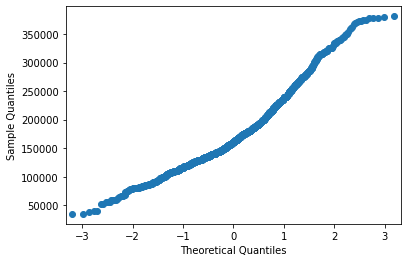

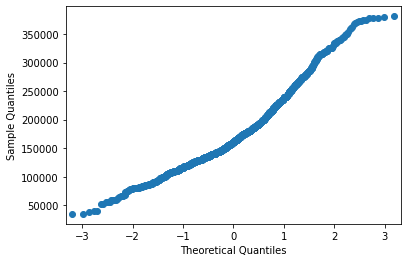

In [28]:
sm.qqplot(target)

2 samples

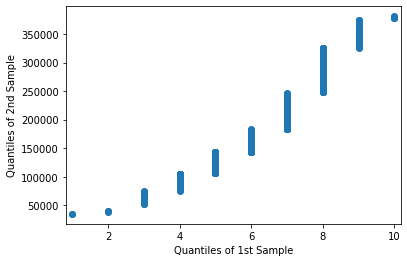

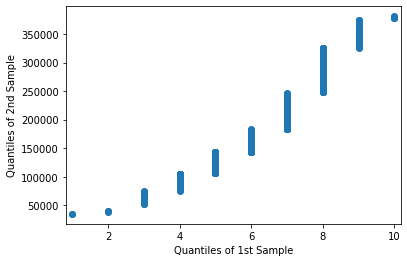

In [29]:
sm.qqplot_2samples(train['OverallQual'], target)

In [30]:
r = np.corrcoef(train['OverallQual'], target)
r

array([[1.       , 0.7921693],
       [0.7921693, 1.       ]])

Define features

In [31]:
features = []

for col in combi:
    if combi[col].dtype=="int":
        features.append(col)
    if combi[col].dtype=='float':
        features.append(col)

print(features)

['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


Normalise combi

In [32]:
combi = combi[features]
combi

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,60,65.0,8450,7,5,2003,2003,196.0,706.0,0.0,...,548.0,0,61,0,0,0,0,0,2,2008
1,20,80.0,9600,6,8,1976,1976,0.0,978.0,0.0,...,460.0,298,0,0,0,0,0,0,5,2007
2,60,68.0,11250,7,5,2001,2002,162.0,486.0,0.0,...,608.0,0,42,0,0,0,0,0,9,2008
3,70,60.0,9550,7,5,1915,1970,0.0,216.0,0.0,...,642.0,0,35,272,0,0,0,0,2,2006
4,60,84.0,14260,8,5,2000,2000,350.0,655.0,0.0,...,836.0,192,84,0,0,0,0,0,12,2008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,160,21.0,1936,4,7,1970,1970,0.0,0.0,0.0,...,0.0,0,0,0,0,0,0,0,6,2006
1455,160,21.0,1894,4,5,1970,1970,0.0,252.0,0.0,...,286.0,0,24,0,0,0,0,0,4,2006
1456,20,160.0,20000,5,7,1960,1996,0.0,1224.0,0.0,...,576.0,474,0,0,0,0,0,0,9,2006
1457,85,62.0,10441,5,5,1992,1992,0.0,337.0,0.0,...,0.0,80,32,0,0,0,0,700,7,2006


In [33]:
combi = (combi - combi.min()) / (combi.max() - combi.min())
combi

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,0.235294,0.150685,0.033420,0.666667,0.500,0.949275,0.883333,0.12250,0.125089,0.0,...,0.368280,0.000000,0.082210,0.000000,0.0,0.0,0.0,0.000000,0.090909,0.50
1,0.000000,0.202055,0.038795,0.555556,0.875,0.753623,0.433333,0.00000,0.173281,0.0,...,0.309140,0.209270,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.363636,0.25
2,0.235294,0.160959,0.046507,0.666667,0.500,0.934783,0.866667,0.10125,0.086109,0.0,...,0.408602,0.000000,0.056604,0.000000,0.0,0.0,0.0,0.000000,0.727273,0.50
3,0.294118,0.133562,0.038561,0.666667,0.500,0.311594,0.333333,0.00000,0.038271,0.0,...,0.431452,0.000000,0.047170,0.268775,0.0,0.0,0.0,0.000000,0.090909,0.00
4,0.235294,0.215753,0.060576,0.777778,0.500,0.927536,0.833333,0.21875,0.116052,0.0,...,0.561828,0.134831,0.113208,0.000000,0.0,0.0,0.0,0.000000,1.000000,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,0.823529,0.000000,0.002973,0.333333,0.750,0.710145,0.333333,0.00000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.454545,0.00
1455,0.823529,0.000000,0.002776,0.333333,0.500,0.710145,0.333333,0.00000,0.044649,0.0,...,0.192204,0.000000,0.032345,0.000000,0.0,0.0,0.0,0.000000,0.272727,0.00
1456,0.000000,0.476027,0.087406,0.444444,0.750,0.637681,0.766667,0.00000,0.216867,0.0,...,0.387097,0.332865,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.727273,0.00
1457,0.382353,0.140411,0.042726,0.444444,0.500,0.869565,0.700000,0.00000,0.059709,0.0,...,0.000000,0.056180,0.043127,0.000000,0.0,0.0,0.0,0.041176,0.545455,0.00


Define X and y

In [34]:
y = target
X = combi[: len(train)]
X_test = combi[len(train) :]

In [35]:
X

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,0.235294,0.150685,0.033420,0.666667,0.500,0.949275,0.883333,0.122500,0.125089,0.000000,...,0.368280,0.000000,0.082210,0.000000,0.0,0.0,0.0,0.000000,0.090909,0.50
1,0.000000,0.202055,0.038795,0.555556,0.875,0.753623,0.433333,0.000000,0.173281,0.000000,...,0.309140,0.209270,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.363636,0.25
2,0.235294,0.160959,0.046507,0.666667,0.500,0.934783,0.866667,0.101250,0.086109,0.000000,...,0.408602,0.000000,0.056604,0.000000,0.0,0.0,0.0,0.000000,0.727273,0.50
3,0.294118,0.133562,0.038561,0.666667,0.500,0.311594,0.333333,0.000000,0.038271,0.000000,...,0.431452,0.000000,0.047170,0.268775,0.0,0.0,0.0,0.000000,0.090909,0.00
4,0.235294,0.215753,0.060576,0.777778,0.500,0.927536,0.833333,0.218750,0.116052,0.000000,...,0.561828,0.134831,0.113208,0.000000,0.0,0.0,0.0,0.000000,1.000000,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,0.235294,0.140411,0.030929,0.555556,0.500,0.920290,0.833333,0.000000,0.000000,0.000000,...,0.309140,0.000000,0.053908,0.000000,0.0,0.0,0.0,0.000000,0.636364,0.25
1456,0.000000,0.219178,0.055505,0.555556,0.625,0.768116,0.633333,0.074375,0.139972,0.106815,...,0.336022,0.245084,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.090909,1.00
1457,0.294118,0.154110,0.036187,0.666667,1.000,0.500000,0.933333,0.000000,0.048724,0.000000,...,0.169355,0.000000,0.080863,0.000000,0.0,0.0,0.0,0.147059,0.363636,1.00
1458,0.000000,0.160959,0.039342,0.444444,0.625,0.565217,0.766667,0.000000,0.008682,0.674312,...,0.161290,0.257022,0.000000,0.110672,0.0,0.0,0.0,0.000000,0.272727,1.00


In [36]:
X_test

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,0.000000,0.202055,0.048246,0.444444,0.625,0.644928,0.183333,0.00000,0.082920,0.094364,...,0.490591,0.098315,0.000000,0.0,0.0,0.208333,0.0,0.000000,0.454545,1.0
1,0.000000,0.205479,0.060609,0.555556,0.625,0.623188,0.133333,0.06750,0.163536,0.000000,...,0.209677,0.275983,0.048518,0.0,0.0,0.000000,0.0,0.735294,0.454545,1.0
2,0.235294,0.181507,0.058566,0.444444,0.500,0.905797,0.800000,0.00000,0.140149,0.000000,...,0.323925,0.148876,0.045822,0.0,0.0,0.000000,0.0,0.000000,0.181818,1.0
3,0.235294,0.195205,0.040562,0.555556,0.625,0.913043,0.800000,0.01250,0.106662,0.000000,...,0.315860,0.252809,0.048518,0.0,0.0,0.000000,0.0,0.000000,0.454545,1.0
4,0.588235,0.075342,0.017318,0.777778,0.500,0.869565,0.700000,0.00000,0.046598,0.000000,...,0.340054,0.000000,0.110512,0.0,0.0,0.250000,0.0,0.000000,0.000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,0.823529,0.000000,0.002973,0.333333,0.750,0.710145,0.333333,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.454545,0.0
1455,0.823529,0.000000,0.002776,0.333333,0.500,0.710145,0.333333,0.00000,0.044649,0.000000,...,0.192204,0.000000,0.032345,0.0,0.0,0.000000,0.0,0.000000,0.272727,0.0
1456,0.000000,0.476027,0.087406,0.444444,0.750,0.637681,0.766667,0.00000,0.216867,0.000000,...,0.387097,0.332865,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.727273,0.0
1457,0.382353,0.140411,0.042726,0.444444,0.500,0.869565,0.700000,0.00000,0.059709,0.000000,...,0.000000,0.056180,0.043127,0.0,0.0,0.000000,0.0,0.041176,0.545455,0.0


Split dataset

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)
X_train.shape, X_val.shape, y_train.shape,y_val.shape, X_test.shape

((1279, 36), (143, 36), (1279,), (143,), (1459, 36))

Select model

In [38]:
model = sm.OLS(y_train, X_train).fit()
print(model.aic)

29821.3398401133


In [39]:
model.conf_int(alpha=0.05, cols=None)

,0,1
MSSubClass,-33173.203287,-17653.134030
LotFrontage,-41546.199606,8244.588597
LotArea,56404.875830,126823.610414
OverallQual,111966.578153,147411.554776
OverallCond,5844.814594,26985.840659
YearBuilt,19257.953924,48603.760062
YearRemodAdd,11838.047259,24647.284009
MasVnrArea,9136.321583,41927.692755
BsmtFinSF1,-4227.142576,40896.041192
BsmtFinSF2,-16020.472951,13061.600645


In [40]:
print(np.mean(X_train))

MSSubClass       0.217633
LotFrontage      0.167046
LotArea          0.042815
OverallQual      0.556946
OverallCond      0.572322
YearBuilt        0.711505
YearRemodAdd     0.571371
MasVnrArea       0.059644
BsmtFinSF1       0.075778
BsmtFinSF2       0.032607
BsmtUnfSF        0.259174
TotalBsmtSF      0.169468
1stFlrSF         0.170590
2ndFlrSF         0.183098
LowQualFinSF     0.005313
GrLivArea        0.218305
BsmtFullBath     0.137086
BsmtHalfBath     0.030884
FullBath         0.387803
HalfBath         0.186083
BedroomAbvGr     0.359754
KitchenAbvGr     0.350274
TotRmsAbvGrd     0.344019
Fireplaces       0.151681
GarageYrBlt      0.264810
GarageCars       0.348866
GarageArea       0.313111
WoodDeckSF       0.063850
OpenPorchSF      0.061945
EnclosedPorch    0.022584
3SsnPorch        0.006155
ScreenPorch      0.026168
PoolArea         0.002831
MiscVal          0.002840
MoSold           0.480631
YrSold           0.453284
dtype: float64


In [41]:
print(np.std(X_train))

MSSubClass       0.250615
LotFrontage      0.075230
LotArea          0.048013
OverallQual      0.146181
OverallCond      0.138397
YearBuilt        0.217628
YearRemodAdd     0.345030
MasVnrArea       0.104846
BsmtFinSF1       0.078667
BsmtFinSF2       0.110488
BsmtUnfSF        0.201310
TotalBsmtSF      0.068876
1stFlrSF         0.077360
2ndFlrSF         0.229093
LowQualFinSF     0.044474
GrLivArea        0.093036
BsmtFullBath     0.172790
BsmtHalfBath     0.123571
FullBath         0.134536
HalfBath         0.249648
BedroomAbvGr     0.101239
KitchenAbvGr     0.076688
TotRmsAbvGrd     0.121384
Fireplaces       0.161415
GarageYrBlt      0.076669
GarageCars       0.146622
GarageArea       0.139633
WoodDeckSF       0.085661
OpenPorchSF      0.088431
EnclosedPorch    0.061815
3SsnPorch        0.056413
ScreenPorch      0.096395
PoolArea         0.045838
MiscVal          0.031127
MoSold           0.244502
YrSold           0.334253
dtype: float64


In [42]:
model.params

MSSubClass       -25413.168658
LotFrontage      -16650.805505
LotArea           91614.243122
OverallQual      129689.066465
OverallCond       16415.327626
YearBuilt         33930.856993
YearRemodAdd      18242.665634
MasVnrArea        25532.007169
BsmtFinSF1        18334.449308
BsmtFinSF2        -1479.436153
BsmtUnfSF           -70.056633
TotalBsmtSF       16541.928051
1stFlrSF          89293.563384
2ndFlrSF          34225.735593
LowQualFinSF        197.970527
GrLivArea         92137.455838
BsmtFullBath      33125.890020
BsmtHalfBath      -1632.641189
FullBath          23632.808594
HalfBath          -2122.716460
BedroomAbvGr     -38292.918729
KitchenAbvGr     -60486.114948
TotRmsAbvGrd      35991.318961
Fireplaces        29061.405199
GarageYrBlt       -9696.788695
GarageCars        53679.829901
GarageArea         7979.649483
WoodDeckSF        43883.248395
OpenPorchSF       12983.628382
EnclosedPorch      3718.455788
3SsnPorch          2326.647749
ScreenPorch       29192.317276
PoolArea

Predict on validation set

In [43]:
y_pred = model.predict(X_val)
y_pred[y_pred < 0] = 0
y_pred = y_pred.astype(int)
y_pred

72      216418
1113    143713
631     220490
51      133226
460     239648
         ...  
1254    210210
1124    192819
870     104082
1256    273637
284     180084
Length: 143, dtype: int64

In [44]:
MSE = np.square(np.subtract(y_val, y_pred)).mean() 
print("MSE", MSE)
 
RMSE = np.sqrt(MSE)
print("RMSE", RMSE)

MSE 419271223.97902095
RMSE 20476.113497903378


In [45]:
df = pd.DataFrame({"Actual": y_val, "Predicted": y_pred})
df

,Actual,Predicted
72,185000.0,216418
1113,134500.0,143713
631,209500.0,220490
51,114500.0,133226
460,263435.0,239648
...,...,...
1254,165400.0,210210
1124,163900.0,192819
870,109500.0,104082
1256,301500.0,273637


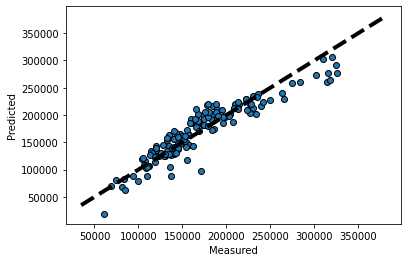

In [46]:
fig, ax = plt.subplots()
ax.scatter(y_val, y_pred, edgecolors=(0, 0, 0))
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=4)
ax.set_xlabel('Measured')
ax.set_ylabel('Predicted')
plt.show()

Predict on test set

In [47]:
prediction = model.predict(X_test)
prediction[prediction < 0] = 0
prediction = prediction.astype(int)
prediction

0       119550
1       154434
2       175884
3       196446
4       189875
         ...  
1454     69188
1455     81817
1456    180085
1457    108127
1458    239898
Length: 1459, dtype: int64

Submit to Kaggle

In [48]:
submission.SalePrice = prediction
submission.to_csv("submission.csv", index=False)
submission = pd.read_csv("submission.csv")
submission

,Id,SalePrice
0,1461,119550
1,1462,154434
2,1463,175884
3,1464,196446
4,1465,189875
...,...,...
1454,2915,69188
1455,2916,81817
1456,2917,180085
1457,2918,108127
